# FCDD localize experiment 8

heatmapy ignorujte tie čo sú tam teraz nefungujú


Epoch 001 | loss=0.160047 | val_auc=0.6914 | val_acc=0.5051 | val_bal_acc=0.6164 | threshold=0.441448
Epoch 002 | loss=0.044905 | val_auc=0.7083 | val_acc=0.5306 | val_bal_acc=0.6330 | threshold=0.224082
Epoch 003 | loss=0.020162 | val_auc=0.7501 | val_acc=0.5969 | val_bal_acc=0.6760 | threshold=0.146764
Epoch 004 | loss=0.010673 | val_auc=0.8107 | val_acc=0.6684 | val_bal_acc=0.7224 | threshold=0.105479
Epoch 005 | loss=0.006101 | val_auc=0.7850 | val_acc=0.6224 | val_bal_acc=0.6926 | threshold=0.087081
Epoch 006 | loss=0.003998 | val_auc=0.8038 | val_acc=0.6582 | val_bal_acc=0.7157 | threshold=0.069355
Epoch 007 | loss=0.002677 | val_auc=0.8425 | val_acc=0.7602 | val_bal_acc=0.7820 | threshold=0.057512
Epoch 008 | loss=0.001906 | val_auc=0.8156 | val_acc=0.6582 | val_bal_acc=0.7157 | threshold=0.046437
Epoch 009 | loss=0.001465 | val_auc=0.7890 | val_acc=0.7092 | val_bal_acc=0.7489 | threshold=0.043926
Epoch 010 | loss=0.001125 | val_auc=0.8088 | val_acc=0.6939 | val_bal_acc=0.7389 |

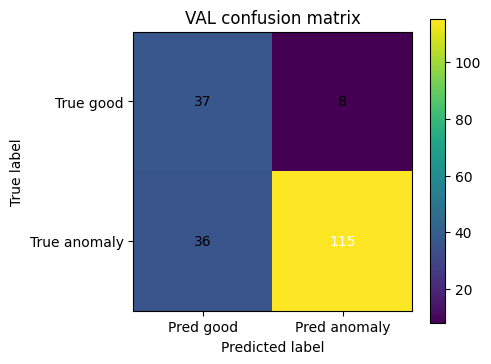

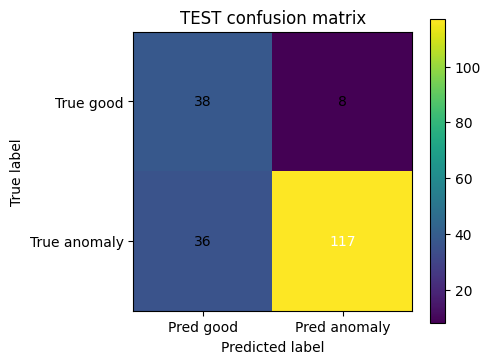

Saved model and outputs to: runs\fcdd_localize


In [2]:
import json
import math
import random
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import List, Dict

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMG_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}


def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


class ImageFolderDataset(Dataset):
    def __init__(self, root: Path, image_size: int = 256, grayscale: bool = False, augment: bool = False):
        self.root = Path(root)
        self.paths = sorted([p for p in self.root.rglob('*') if p.suffix.lower() in IMG_EXTS])
        if not self.paths:
            raise FileNotFoundError(f'No images found in {self.root}')

        ops = []
        if grayscale:
            ops.append(transforms.Grayscale(num_output_channels=1))
        else:
            ops.append(transforms.Lambda(lambda img: img.convert('RGB')))

        if augment:
            ops.extend([
                transforms.Resize((image_size, image_size)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(degrees=8),
                transforms.ColorJitter(brightness=0.08, contrast=0.08),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.5], std=[0.5]) if grayscale
                else transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
            ])
        else:
            ops.extend([
                transforms.Resize((image_size, image_size)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.5], std=[0.5]) if grayscale
                else transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
            ])

        self.tf = transforms.Compose(ops)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx: int):
        path = self.paths[idx]
        img = Image.open(path)
        x = self.tf(img)
        return x, str(path)


@torch.no_grad()
def collect_scores(model, loader, device):
    model.eval()
    y_true, y_score = [], []
    for x, y, _ in loader:
        x = x.to(device)
        hm = model(x)
        s = masked_topk_score(hm, x).cpu().numpy()
        y_true.extend(np.asarray(y).tolist())
        y_score.extend(s.tolist())
    return np.asarray(y_true), np.asarray(y_score)


def find_best_threshold(y_true, y_score):
    unique_scores = np.unique(y_score)
    if len(unique_scores) == 1:
        thr = float(unique_scores[0])
        y_pred = (y_score >= thr).astype(int)
        acc = float((y_pred == y_true).mean())
        return thr, acc

    candidates = []
    candidates.append(unique_scores[0] - 1e-6)
    for i in range(len(unique_scores) - 1):
        candidates.append((unique_scores[i] + unique_scores[i + 1]) / 2.0)
    candidates.append(unique_scores[-1] + 1e-6)

    best_thr = candidates[0]
    best_acc = -1.0

    for thr in candidates:
        y_pred = (y_score >= thr).astype(int)
        acc = float((y_pred == y_true).mean())
        if acc > best_acc:
            best_acc = acc
            best_thr = thr

    return float(best_thr), float(best_acc)


class FCDDDataset(Dataset):
    def __init__(self, good_root: Path, anomaly_root: Path, image_size: int = 256, grayscale: bool = False):
        self.good = ImageFolderDataset(good_root, image_size=image_size, grayscale=grayscale, augment=False)
        self.anomaly = ImageFolderDataset(anomaly_root, image_size=image_size, grayscale=grayscale, augment=False)
        self.items = [(0, i) for i in range(len(self.good))] + [(1, i) for i in range(len(self.anomaly))]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx: int):
        label, inner_idx = self.items[idx]
        ds = self.good if label == 0 else self.anomaly
        x, path = ds[inner_idx]
        return x, label, path


class ConvBlock(nn.Module):
    def __init__(self, c_in: int, c_out: int, stride: int = 1, dilation: int = 1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(
                c_in,
                c_out,
                kernel_size=3,
                stride=stride,
                padding=dilation,
                dilation=dilation,
                bias=False,
            ),
            nn.BatchNorm2d(c_out),
            nn.LeakyReLU(0.1, inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class FCDDNet(nn.Module):
    """
    Vyššie priestorové rozlíšenie ako v pôvodnej verzii:
    - len 2x downsampling (nie 3x)
    - potom dilated conv vrstvy
    - výsledok je ostrejší anomaly map
    """
    def __init__(self, in_channels: int = 1, base: int = 32):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(in_channels, base),
            ConvBlock(base, base),
            ConvBlock(base, base * 2, stride=2),
            ConvBlock(base * 2, base * 2),
            ConvBlock(base * 2, base * 4, stride=2),
            ConvBlock(base * 4, base * 4),
            ConvBlock(base * 4, base * 4, dilation=2),
            ConvBlock(base * 4, base * 4, dilation=2),
            nn.Conv2d(base * 4, base * 2, kernel_size=1),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(base * 2, 1, kernel_size=1),
        )

    def forward(self, x):
        heatmap = self.features(x)
        heatmap = F.softplus(heatmap)
        return heatmap


@dataclass
class Metrics:
    epoch: int
    train_loss: float
    val_auc: float
    threshold: float
    val_acc: float
    val_bal_acc: float


def binary_auc(y_true: List[int], y_score: List[float]) -> float:
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    pos = y_score[y_true == 1]
    neg = y_score[y_true == 0]
    if len(pos) == 0 or len(neg) == 0:
        return float('nan')
    wins = 0.0
    total = 0
    for p in pos:
        wins += np.sum(p > neg)
        wins += 0.5 * np.sum(p == neg)
        total += len(neg)
    return float(wins / total)


def object_mask_from_input(x: torch.Tensor, thr: float = 0.7, out_size=None) -> torch.Tensor:
    """
    Maska objektu z normalizovaného inputu.
    Po Normalize(mean=0.5, std=0.5) je svetlé pozadie skôr pri +1,
    tmavší objekt bližšie k záporným/nižším hodnotám.
    """
    g = x.mean(dim=1, keepdim=True)
    mask = (g < thr).float()
    mask = F.max_pool2d(mask, kernel_size=7, stride=1, padding=3)

    if out_size is not None and mask.shape[-2:] != out_size:
        mask = F.interpolate(mask, size=out_size, mode='nearest')

    return mask


def masked_topk_score(heatmap: torch.Tensor, x: torch.Tensor, topk_ratio: float = 0.02) -> torch.Tensor:
    mask = object_mask_from_input(x, out_size=heatmap.shape[-2:])
    masked_heat = heatmap * mask
    b, c, h, w = masked_heat.shape
    k = max(1, int(h * w * topk_ratio))
    vals = masked_heat.flatten(1)
    topk = torch.topk(vals, k=k, dim=1).values
    return topk.mean(dim=1)


@torch.no_grad()
def compute_threshold(model, loader, device, q: float = 0.99) -> float:
    model.eval()
    scores = []
    for batch in loader:
        x = batch[0].to(device)
        hm = model(x)
        s = masked_topk_score(hm, x)
        scores.extend(s.cpu().numpy().tolist())
    return float(np.quantile(scores, q))


@torch.no_grad()
def evaluate(model, loader, device, threshold: float) -> Dict[str, float]:
    model.eval()
    y_true, y_score, y_pred = [], [], []
    for x, y, _ in loader:
        x = x.to(device)
        hm = model(x)
        s = masked_topk_score(hm, x).cpu().numpy()
        y_np = np.asarray(y)
        y_true.extend(y_np.tolist())
        y_score.extend(s.tolist())
        y_pred.extend((s >= threshold).astype(int).tolist())

    y_true_np = np.asarray(y_true)
    y_pred_np = np.asarray(y_pred)
    acc = float((y_true_np == y_pred_np).mean())
    auc = binary_auc(y_true, y_score)
    return {'acc': acc, 'auc': auc}




def confusion_counts(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, int]:
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    return {'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp}


def balanced_accuracy_from_counts(counts: Dict[str, int]) -> float:
    good_recall = counts['tn'] / max(1, counts['tn'] + counts['fp'])
    anomaly_recall = counts['tp'] / max(1, counts['tp'] + counts['fn'])
    return 0.5 * (good_recall + anomaly_recall)

@torch.no_grad()
def evaluate_with_confusion(model, loader, device, threshold: float) -> Dict[str, float]:
    model.eval()
    y_true, y_score, y_pred = [], [], []

    for x, y, _ in loader:
        x = x.to(device)
        hm = model(x)
        s = masked_topk_score(hm, x).cpu().numpy()
        y_np = np.asarray(y)
        pred_np = (s >= threshold).astype(int)

        y_true.extend(y_np.tolist())
        y_score.extend(s.tolist())
        y_pred.extend(pred_np.tolist())

    y_true_np = np.asarray(y_true)
    y_pred_np = np.asarray(y_pred)

    counts = confusion_counts(y_true_np, y_pred_np)
    acc = float((y_true_np == y_pred_np).mean())
    auc = binary_auc(y_true, y_score)

    return {
        'acc': acc,
        'auc': auc,
        'tn': counts['tn'],
        'fp': counts['fp'],
        'fn': counts['fn'],
        'tp': counts['tp'],
    }


def save_confusion_matrix_figure(cm: np.ndarray, out_path: Path, title: str, show_inline: bool = False) -> None:
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation='nearest')
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(2),
        yticks=np.arange(2),
        xticklabels=['Pred good', 'Pred anomaly'],
        yticklabels=['True good', 'True anomaly'],
        title=title,
        ylabel='True label',
        xlabel='Predicted label',
    )

    thresh = cm.max() / 2.0 if cm.size else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                f'{int(cm[i, j])}',
                ha='center',
                va='center',
                color='white' if cm[i, j] > thresh else 'black',
            )

    fig.tight_layout()
    fig.savefig(out_path, dpi=180, bbox_inches='tight')

    if show_inline:
        plt.show()

    plt.close(fig)


def save_confusion_outputs(metrics: Dict[str, float], out_dir: Path, split_name: str, show_inline: bool = False) -> None:
    out_dir.mkdir(parents=True, exist_ok=True)

    cm = np.array([
        [metrics['tn'], metrics['fp']],
        [metrics['fn'], metrics['tp']],
    ], dtype=np.int64)

    payload = {
        'split': split_name,
        'accuracy': float(metrics['acc']),
        'auc': float(metrics['auc']),
        'threshold': float(metrics.get('threshold', 0.0)),
        'confusion_matrix': {
            'rows': ['true_good', 'true_anomaly'],
            'cols': ['pred_good', 'pred_anomaly'],
            'values': cm.tolist(),
        },
        'counts': {
            'tn': int(metrics['tn']),
            'fp': int(metrics['fp']),
            'fn': int(metrics['fn']),
            'tp': int(metrics['tp']),
        }
    }

    with open(out_dir / f'{split_name}_confusion_matrix.json', 'w', encoding='utf-8') as f:
        json.dump(payload, f, indent=2)

    with open(out_dir / f'{split_name}_confusion_matrix.txt', 'w', encoding='utf-8') as f:
        f.write(f'{split_name.upper()} confusion matrix\n')
        f.write('                Pred good   Pred anomaly\n')
        f.write(f'True good      {cm[0,0]:10d}   {cm[0,1]:12d}\n')
        f.write(f'True anomaly   {cm[1,0]:10d}   {cm[1,1]:12d}\n')
        f.write(f'\nAccuracy: {payload["accuracy"]:.6f}\n')
        f.write(f'AUC:      {payload["auc"]:.6f}\n')
        f.write(f'Threshold:{payload["threshold"]:.6f}\n')

    save_confusion_matrix_figure(
        cm,
        out_dir / f'{split_name}_confusion_matrix.png',
        f'{split_name.upper()} confusion matrix',
        show_inline=show_inline
    )


@torch.no_grad()
def save_heatmaps(model, loader, device, out_dir: Path, image_size: int, limit_per_class: int = 20) -> None:
    out_dir.mkdir(parents=True, exist_ok=True)
    model.eval()

    saved_good = 0
    saved_anomaly = 0

    for x, y, paths in loader:
        x = x.to(device)
        hm = model(x)
        hm_up = F.interpolate(hm, size=(image_size, image_size), mode='bilinear', align_corners=False)
        hm_up = hm_up.squeeze(1).cpu().numpy()
        imgs = x.cpu().numpy()

        for img, heat, label, path in zip(imgs, hm_up, y, paths):
            label = int(label)

            if label == 0 and saved_good >= limit_per_class:
                continue
            if label == 1 and saved_anomaly >= limit_per_class:
                continue

            if img.shape[0] == 1:
                base = np.repeat(img.transpose(1, 2, 0), 3, axis=2)
            else:
                base = img.transpose(1, 2, 0)
            base = np.clip(base, 0, 1)

            obj_mask = (base.mean(axis=2) < 0.92).astype(np.float32)
            heat = np.maximum(heat, 0.0) * obj_mask

            obj_vals = heat[obj_mask > 0]
            if obj_vals.size == 0:
                lo, hi = 0.0, 1.0
            else:
                lo = np.percentile(obj_vals, 85)
                hi = np.percentile(obj_vals, 99.5)
                if hi <= lo:
                    hi = lo + 1e-6

            heat_norm = np.clip((heat - lo) / (hi - lo + 1e-8), 0, 1)
            heat_norm[heat_norm < 0.10] = 0.0

            
            alpha = 0.85 * heat_norm
            overlay = base.copy()
            overlay[..., 0] = np.clip(overlay[..., 0] + alpha, 0, 1)
            overlay[..., 1] = overlay[..., 1] * (1.0 - alpha)
            overlay[..., 2] = overlay[..., 2] * (1.0 - alpha)

            raw_heat = (heat_norm * 255).astype(np.uint8)

            stem = Path(path).stem
            if label == 0:
                prefix = f'good_{saved_good:03d}'
                saved_good += 1
            else:
                prefix = f'anomaly_{saved_anomaly:03d}'
                saved_anomaly += 1

            Image.fromarray((base * 255).astype(np.uint8)).save(out_dir / f'{prefix}_{stem}_img.png')
            Image.fromarray(raw_heat).save(out_dir / f'{prefix}_{stem}_heat.png')
            Image.fromarray((overlay * 255).astype(np.uint8)).save(out_dir / f'{prefix}_{stem}_overlay.png')

        if saved_good >= limit_per_class and saved_anomaly >= limit_per_class:
            break


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total = 0.0
    for x, _ in loader:
        x = x.to(device)
        heatmap = model(x)
        mask = object_mask_from_input(x, out_size=heatmap.shape[-2:])

        loss = ((heatmap * mask) ** 2).sum() / (mask.sum() + 1e-6)
        loss = loss + 1e-6 * torch.mean(torch.abs(heatmap * mask))

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total += float(loss.item()) * x.size(0)
    return total / len(loader.dataset)


def make_loaders(root: Path, image_size: int, batch_size: int, grayscale: bool):
    train_good = root / 'train' / 'good'
    val_good = root / 'val' / 'good'
    val_anomaly = root / 'val' / 'anomaly'
    test_good = root / 'test' / 'good'
    test_anomaly = root / 'test' / 'anomaly'

    train_ds = ImageFolderDataset(train_good, image_size=image_size, grayscale=grayscale, augment=False)
    val_ds = FCDDDataset(val_good, val_anomaly, image_size=image_size, grayscale=grayscale)
    test_ds = FCDDDataset(test_good, test_anomaly, image_size=image_size, grayscale=grayscale)
    val_good_ds = ImageFolderDataset(val_good, image_size=image_size, grayscale=grayscale, augment=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    val_good_loader = DataLoader(val_good_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader, val_good_loader


def main():
    DATA_ROOT = r'C:\Users\Jakub\Desktop\skola new\Tímový projekt\dataset_splits\ae_fcdd'
    IMAGE_SIZE = 384
    BATCH_SIZE = 8
    EPOCHS = 50
    LR = 1e-4
    WEIGHT_DECAY = 1e-6
    THRESHOLD_Q = 0.99
    BASE_CHANNELS = 32
    GRAYSCALE = False
    SEED = 42
    OUT_DIR = 'runs/fcdd_localize'

    seed_everything(SEED)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    root = Path(DATA_ROOT)
    out_dir = Path(OUT_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)

    train_loader, val_loader, test_loader, val_good_loader = make_loaders(
        root=root,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        grayscale=GRAYSCALE,
    )

    in_channels = 1 if GRAYSCALE else 3
    model = FCDDNet(in_channels=in_channels, base=BASE_CHANNELS).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_bal_acc = -math.inf
    history = []

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, device)

        y_true_val, y_score_val = collect_scores(model, val_loader, device)
        val_auc = binary_auc(y_true_val.tolist(), y_score_val.tolist())

        threshold = compute_threshold(model, val_good_loader, device, q=0.82)
        y_pred_val = (y_score_val >= threshold).astype(int)

        val_counts = confusion_counts(y_true_val, y_pred_val)
        val_acc = float((y_pred_val == y_true_val).mean())
        val_bal_acc = balanced_accuracy_from_counts(val_counts)

        metrics = Metrics(
            epoch=epoch,
            train_loss=train_loss,
            val_auc=val_auc,
            threshold=threshold,
            val_acc=val_acc,
            val_bal_acc=val_bal_acc,
        )
        history.append(asdict(metrics))

        print(
            f"Epoch {epoch:03d} | loss={train_loss:.6f} | "
            f"val_auc={metrics.val_auc:.4f} | val_acc={metrics.val_acc:.4f} | "
            f"val_bal_acc={metrics.val_bal_acc:.4f} | threshold={threshold:.6f}"
        )

        if metrics.val_bal_acc > best_bal_acc:
            best_bal_acc = metrics.val_bal_acc
            torch.save(
                {
                    'model_state': model.state_dict(),
                    'best_metrics': asdict(metrics),
                },
             out_dir / 'best_fcdd.pt',
            )

    with open(out_dir / 'history.json', 'w', encoding='utf-8') as f:
        json.dump(history, f, indent=2)

    checkpoint = torch.load(out_dir / 'best_fcdd.pt', map_location=device)
    model.load_state_dict(checkpoint['model_state'])
    threshold = checkpoint['best_metrics']['threshold']

    test_metrics = evaluate_with_confusion(model, test_loader, device, threshold)
    test_metrics['threshold'] = float(threshold)

    val_metrics_best = {
        'acc': float(checkpoint['best_metrics']['val_acc']),
        'bal_acc': float(checkpoint['best_metrics']['val_bal_acc']),
        'auc': float(checkpoint['best_metrics']['val_auc']),
    }
    y_true_val, y_score_val = collect_scores(model, val_loader, device)
    y_pred_val = (y_score_val >= threshold).astype(int)
    val_counts = confusion_counts(y_true_val, y_pred_val)
    val_metrics_best.update(val_counts)
    val_metrics_best['threshold'] = float(threshold)

    print('=== BEST VALIDATION ===')
    print(json.dumps(checkpoint['best_metrics'], indent=2))
    print('=== VALIDATION CONFUSION ===')
    print(json.dumps(val_metrics_best, indent=2))
    print('=== TEST ===')
    print(json.dumps(test_metrics, indent=2))

    with open(out_dir / 'test_metrics.json', 'w', encoding='utf-8') as f:
        json.dump(test_metrics, f, indent=2)

    save_confusion_outputs(val_metrics_best, out_dir, 'val', show_inline=True)
    save_confusion_outputs(test_metrics, out_dir, 'test', show_inline=True)

    save_heatmaps(model, test_loader, device, out_dir / 'heatmaps', image_size=IMAGE_SIZE, limit_per_class=60)
    print(f'Saved model and outputs to: {out_dir}')


if __name__ == '__main__':
    main()
